# Charge-to-Mass Ratio of the Electron

## Introduction

This notebook measures the electron's charge-to-mass ratio, $e/m$, by observing the circular
path traced by an electron beam in a magnetic field.

An electron beam accelerated through a potential difference $V$ gains kinetic energy

$$eV = \frac{1}{2}mv^2 \tag{1}$$

When that beam passes through a uniform magnetic field $B$ (produced here by a pair of
Helmholtz coils), the magnetic force provides the centripetal force needed to bend the beam
into a circle of radius $r$:

$$evB = \frac{mv^2}{r} \tag{2}$$

Combining (1) and (2) to eliminate $v$ gives a relationship between the accelerating voltage
and the radius of curvature:

$$\frac{1}{r} = \sqrt{\frac{e}{2mV}}\, B \tag{3}$$

The field itself comes from the Helmholtz coil pair carrying current $I$:

$$B_c = \left(\frac{4}{5}\right)^{3/2} \frac{\mu_0 n I}{R} \tag{4}$$

where $n$ is the number of turns per coil and $R$ is the coil radius. Since the coils don't
produce the only field present, the total field is the coil field plus a (roughly constant)
external field &mdash; nominally the Earth's field, $B_e$:

$$B = B_c + B_e \tag{5}$$

Putting (3)-(5) together, and defining the constant

$$k = \frac{1}{\sqrt{2}} \left(\frac{4}{5}\right)^{3/2} \frac{\mu_0 n}{R} \tag{6}$$

gives the working equation for the experiment:

$$\frac{1}{r} = \sqrt{\frac{e}{m}}\, \frac{1}{\sqrt{V}} \left(kI + \frac{B_e}{\sqrt{2}}\right) \tag{7}$$

The key feature of (7) is that **at fixed $V$, $1/r$ is linear in $I$**: the slope of that line
gives $e/m$, and the intercept gives the external field $B_e$. That's the basis for Part 1
below. Fixing $I$ instead and varying $V$ (Part 2) gives a complementary check, since (7)
predicts $1/r \propto 1/\sqrt{V}$ in that case. Part 3 collapses every fixed-voltage run onto
the same $I/\sqrt{V}$ axis as a visual consistency check across all voltages.

This experiment has three different parts: 
- **Part 1:** Voltage fixed, current varied &rarr; linear fit of $1/r$ vs. $I$ for each voltage, giving $e/m$ and $B_e$ per voltage.
- **Part 2:** Current fixed, voltage varied &rarr; fit of $1/r$ vs. $1/\sqrt{V}$.
- **Part 3:** All fixed-voltage runs collapsed onto a single $I/\sqrt{V}$ vs. $1/r$ plot, to sanity-check that equation (7) holds across all voltages.



## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


## Constants

$k$ is meant to be equation (8) from the report:

$$k = \frac{1}{\sqrt{2}} \left(\frac{4}{5}\right)^{3/2} \frac{\mu_0 N}{R}$$



In [ ]:
N = 130       # Number of turns per Helmholtz coil
R = 0.155     # Radius of Helmholtz coils, m
uR = 0.01     # Uncertainty in coil radius, m
MU_0 = 4 * np.pi * 1e-7   # Permeability of free space, T*m/A

k = (1 / np.sqrt(2)) * ((4 / 5) ** 3 / 2) * (MU_0 * N / R) 
uk = uR * R * k   # uncertainty in k


## Helper functions

Fitting model and standard error-propagation / goodness-of-fit helpers used throughout the notebook.

In [3]:
def linear_rel(x, slope, intercept):
    """Simple linear model y = slope * x + intercept, used for curve_fit."""
    return slope * x + intercept


def inverse_sqrt_rel(x, a, b):
    """Model y = a / sqrt(x) + b, used for the fixed-current fit (eq. 12 in the report)."""
    return a / np.sqrt(x) + b


def uncert_product3(x, y, z, ux, uy, uz):
    """Propagated uncertainty for a product/quotient of three quantities, w = x*y*z (or x/(y*z))."""
    return x * y * z * np.sqrt((ux / x) ** 2 + (uy / y) ** 2 + (uz / z) ** 2)


def uncert_product2(x, y, ux, uy):
    """Propagated uncertainty for a product of two quantities, w = x*y."""
    return x * y * np.sqrt((ux / x) ** 2 + (uy / y) ** 2)


def uncert_add(ux, uy):
    """Propagated uncertainty for a sum/difference, w = x + y."""
    return np.sqrt(ux ** 2 + uy ** 2)


def uncert_power(z, uz, n):
    """Propagated uncertainty for a power law, w = z**n."""
    return abs(n) * z ** (n - 1) * uz


def reduced_chi_squared(y_data, y_expected, sigma, n_points, n_params):
    """Reduced chi-squared statistic for a fit with n_params free parameters."""
    y_data = np.asarray(y_data)
    y_expected = np.asarray(y_expected)
    sigma = np.asarray(sigma)
    chisq = np.sum(((y_data - y_expected) / sigma) ** 2)
    return chisq / (n_points - n_params)


## Part 1: Fixed voltage, varying current

For each fixed voltage, the beam diameter was stepped down from 12.0 cm to 7.0 cm in 0.5 cm
increments and the corresponding current was recorded. `inv_radius1` (in 1/m) is common to every
voltage; `curr` and `curr_uncert` hold one row per voltage, in the same order as `volts`.


In [4]:
inv_radius1 = [200 / d for d in [12, 11.5, 11, 10.5, 10, 9.5, 9, 8.5, 8]]  # 1/m
volts = [109, 140, 161, 199, 239, 280, 320]  # V
volt_uncert = 1  # V, same for every fixed-voltage run

curr = [
    [0.7100, 0.7440, 0.7985, 0.8225, 0.8915, 0.9675, 1.0135, 1.0895, 1.1415],  # 109 V
    [0.8100, 0.8500, 0.8950, 0.9200, 0.9650, 1.0230, 1.0820, 1.1790, 1.2360],  # 140 V
    [0.8865, 0.9415, 0.9745, 1.0045, 1.0405, 1.1135, 1.1765, 1.2575, 1.3540],  # 161 V
    [1.0010, 1.0560, 1.0825, 1.1350, 1.2130, 1.2805, 1.3485, 1.4465, 1.5170],  # 199 V
    [1.1130, 1.1540, 1.1925, 1.2645, 1.3290, 1.3920, 1.4940, 1.5700, 1.6400],  # 239 V
    [1.2145, 1.2710, 1.3080, 1.3790, 1.4490, 1.5510, 1.6370, 1.7130, 1.8130],  # 280 V
    [1.2830, 1.3380, 1.3990, 1.4500, 1.5290, 1.5970, 1.7040, 1.7500, 1.8890],  # 320 V
]  # A

curr_uncert = [
    [0.0050] * 9,   # 109 V
    [0.0010] * 9,   # 140 V
    [0.0005] * 9,   # 161 V
    [0.0005] * 9,   # 199 V
    [0.0005] * 9,   # 239 V
    [0.0005] * 9,   # 280 V
    [0.0005] * 9,   # 320 V
]  # A


### Fixed-voltage fit routine

Fits $1/r = kI \cdot \sqrt{e/m}/\sqrt{V} + \text{intercept}$ (linear in $I$ for fixed $V$), then converts the slope/intercept into $e/m$ and $B_e$.

In [5]:
def fit_fixed_voltage(inv_radius, currents, current_uncert, voltage, voltage_uncert=1, make_plots=True):
    """
    Linear-fit 1/r vs. current at a single fixed voltage and return the derived
    charge-to-mass ratio and external magnetic field.

    Returns
    -------
    (e_over_m, u_e_over_m), (B_e, u_B_e), chi_squared_reduced
    """
    popt, pcov = curve_fit(
        linear_rel, currents, inv_radius, sigma=current_uncert, absolute_sigma=True
    )
    slope, intercept = popt
    slope_err, intercept_err = np.sqrt(np.diag(pcov))
    fitted = linear_rel(np.asarray(currents), *popt)

    # Uncertainty in radius is assumed constant (scale reading uncertainty); propagate to 1/r.
    radius_uncert = 0.003  # m
    inv_radius_uncert = [radius_uncert * r for r in inv_radius]  # d(1/r) ~ (1/r) * (dr/r)

    sqrt_volt_uncert = 0.5 / np.sqrt(voltage) * voltage_uncert  # d(sqrt(V))

    e_over_m = (slope * np.sqrt(voltage) / k) ** 2
    B_e = intercept * np.sqrt(2) * np.sqrt(voltage) / e_over_m

    # Propagate uncertainty in e/m: e/m = (slope * sqrt(V) / k)^2
    sqrt_em_uncert = e_over_m * uncert_product3(
        1 / np.sqrt(voltage), k, slope, sqrt_volt_uncert, uk, slope_err
    )
    e_over_m_uncert = 0.5 / np.sqrt(e_over_m) * sqrt_em_uncert
    B_e_uncert = uncert_product2(1 / np.sqrt(voltage), intercept, sqrt_volt_uncert, intercept_err)

    chi2_red = reduced_chi_squared(inv_radius, fitted, inv_radius_uncert, len(currents), 2)

    if make_plots:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

        ax1.errorbar(currents, inv_radius, xerr=current_uncert, yerr=inv_radius_uncert,
                     ls='', marker='.', label='data')
        ax1.plot(currents, fitted, label='Curve fit', color='C1')
        ax1.set_xlabel('Measured Current (A)')
        ax1.set_ylabel('Inverse of the Radius of the Ring (1/m)')
        ax1.set_title(f'1/r vs. I  (V = {voltage} V)')
        ax1.grid(True)
        ax1.legend()

        residuals = np.asarray(inv_radius) - fitted
        ax2.errorbar(currents, residuals, xerr=current_uncert, yerr=inv_radius_uncert,
                     ls='', marker='.')
        ax2.axhline(0, color='r', linestyle='--')
        ax2.set_xlabel('Measured Current (A)')
        ax2.set_ylabel('Residuals (1/m)')
        ax2.set_title(f'Residuals  (V = {voltage} V)')
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

    print(f"V = {voltage} V:  slope = {slope:.4f} +- {slope_err:.4f},  "
          f"intercept = {intercept:.4f} +- {intercept_err:.4f},  chi^2_red = {chi2_red:.4f}")

    return (e_over_m, e_over_m_uncert), (B_e, B_e_uncert), chi2_red


### Run the fit for every fixed voltage

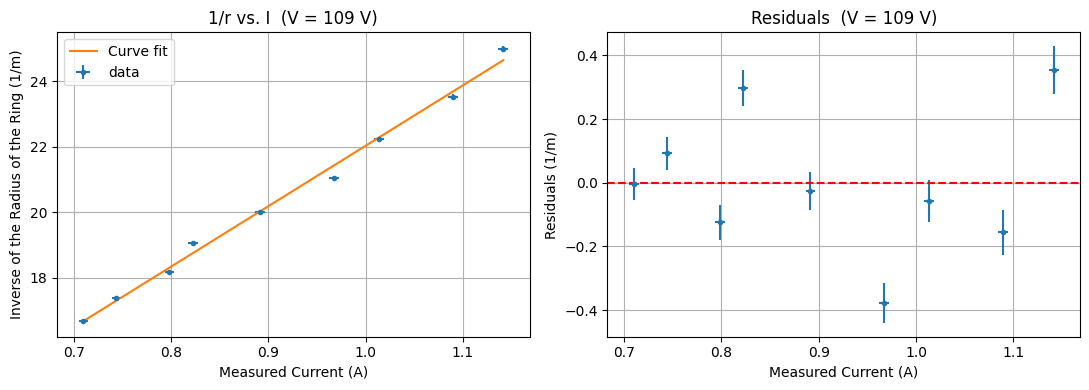

V = 109 V:  slope = 18.4836 +- 0.0115,  intercept = 3.5471 +- 0.0106,  chi^2_red = 14.1785


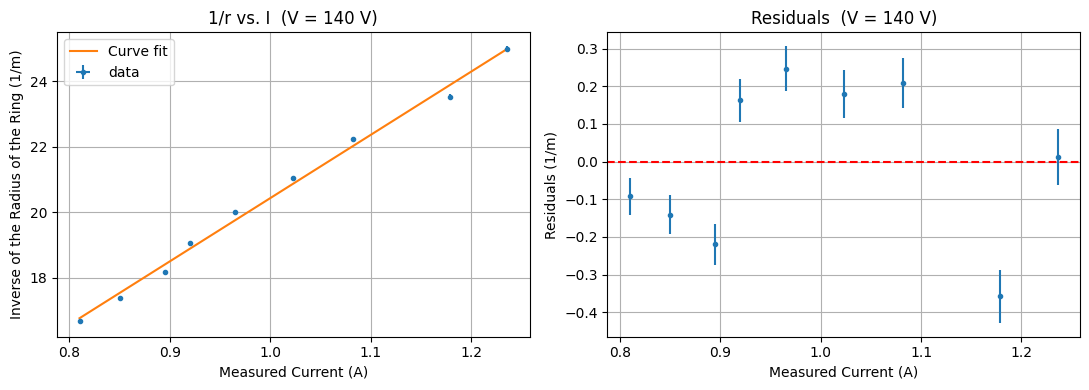

V = 140 V:  slope = 19.3167 +- 0.0024,  intercept = 1.1127 +- 0.0024,  chi^2_red = 13.6420


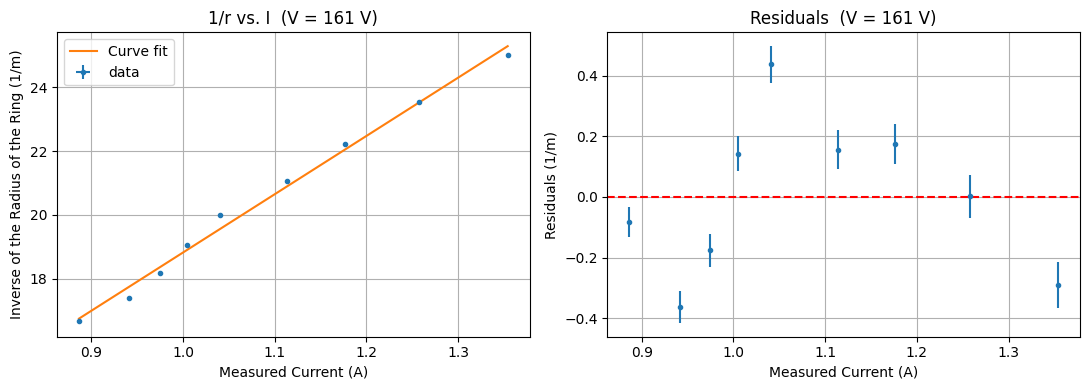

V = 161 V:  slope = 18.2675 +- 0.0011,  intercept = 0.5557 +- 0.0012,  chi^2_red = 21.2512


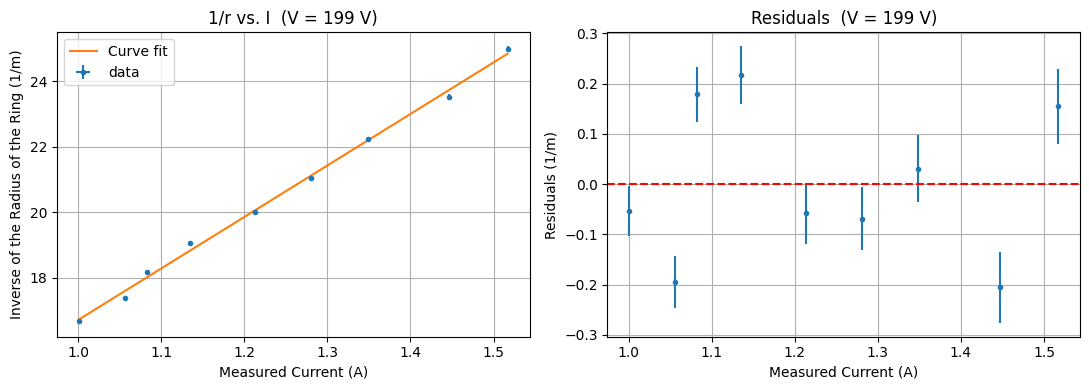

V = 199 V:  slope = 15.7470 +- 0.0010,  intercept = 0.9572 +- 0.0012,  chi^2_red = 7.9074


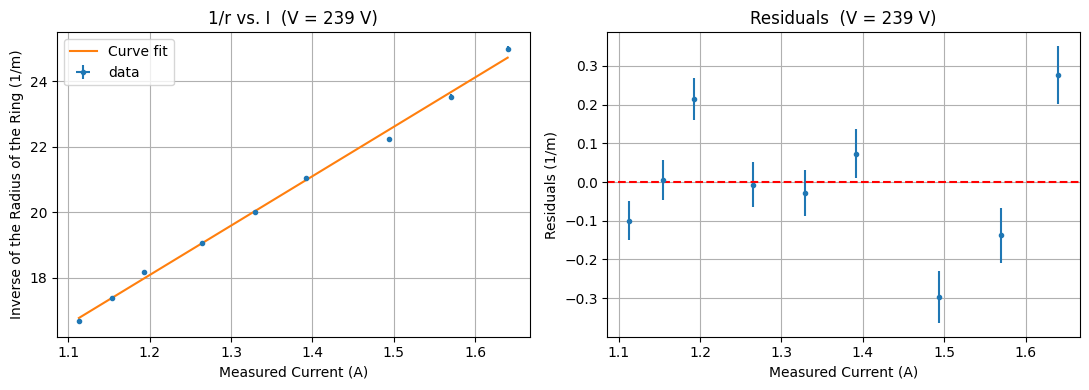

V = 239 V:  slope = 15.0992 +- 0.0009,  intercept = -0.0387 +- 0.0013,  chi^2_red = 8.3313


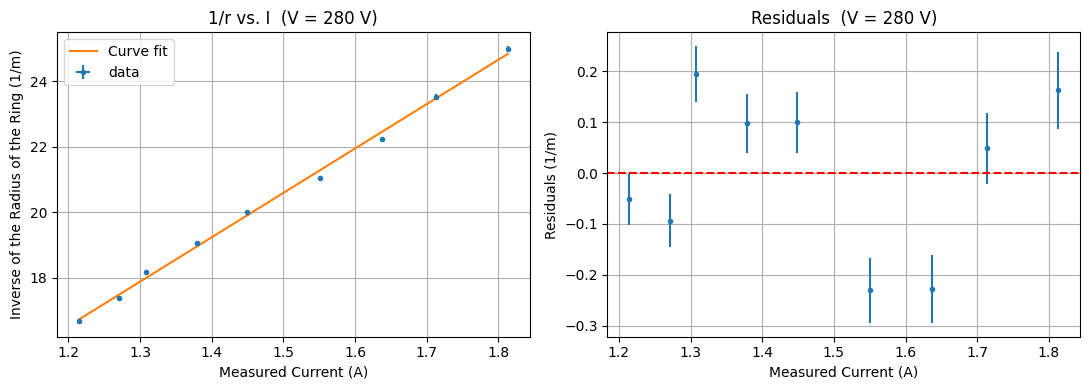

V = 280 V:  slope = 13.5659 +- 0.0008,  intercept = 0.2426 +- 0.0013,  chi^2_red = 7.5659


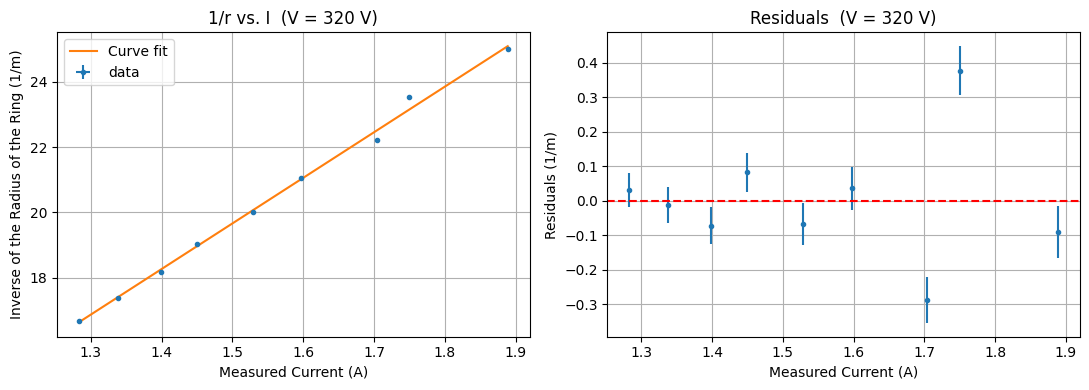

V = 320 V:  slope = 13.9542 +- 0.0009,  intercept = -1.2685 +- 0.0014,  chi^2_red = 7.7966


In [6]:
results = []
for v_idx, voltage in enumerate(volts):
    result = fit_fixed_voltage(
        inv_radius1, curr[v_idx], curr_uncert[v_idx], voltage, volt_uncert
    )
    results.append(result)


## Part 2: Fixed current, varying voltage

At fixed current, the term in parentheses in equation (7) is constant, so $1/r$ depends only on $V$:

$$\frac{1}{r} = \sqrt{\frac{e}{m}}\left(kI + \frac{B_e}{\sqrt{2}}\right)\frac{1}{\sqrt{V}} \tag{8}$$

which has the form $1/r = a/\sqrt{V} + b$ — a two-parameter fit in $1/\sqrt{V}$, with

$$a = \sqrt{\frac{e}{m}}\left(kI + \frac{B_e}{\sqrt{2}}\right)$$

and $b$ an empirical offset accounting for any residual (e.g. second-order) effects not captured by the idealized model. This is the model fit below.

Note the current is held at $(1.41 \pm 0.01)$.


a = 345.227 +- 4.638
b = -1.378 +- 0.342
chi^2_red = 11.2715


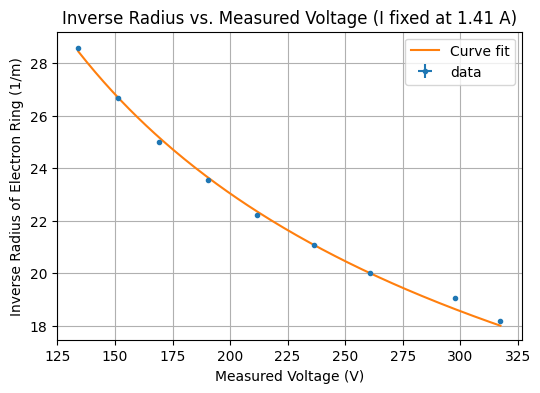

In [8]:
fixed_current = 1.41       # A
fixed_current_uncert = 0.01  # A

inv_radius2 = [200 / d for d in [11, 10.5, 10, 9.5, 9, 8.5, 8, 7.5, 7]]  # 1/m
volt2 = [317.5, 297.7, 261.0, 236.7, 211.5, 190.6, 169.1, 151.5, 134.1]  # V
volt2_uncert = [0.2, 0.2, 0.5, 0.1, 0.1, 0.1, 0.2, 0.1, 0.1]  # V

radius_uncert = 0.003  # m
inv_radius2_uncert = [radius_uncert * r for r in inv_radius2]

popt2, pcov2 = curve_fit(
    inverse_sqrt_rel, volt2, inv_radius2, sigma=volt2_uncert, absolute_sigma=True
)
a_fit, b_fit = popt2
a_err, b_err = np.sqrt(np.diag(pcov2))
fitted2 = inverse_sqrt_rel(np.asarray(volt2), *popt2)

chi2_red_fixed_current = reduced_chi_squared(inv_radius2, fitted2, inv_radius2_uncert, len(volt2), 2)

print(f"a = {a_fit:.3f} +- {a_err:.3f}")
print(f"b = {b_fit:.3f} +- {b_err:.3f}")
print(f"chi^2_red = {chi2_red_fixed_current:.4f}")

plt.figure(figsize=(6, 4))
plt.errorbar(volt2, inv_radius2, xerr=volt2_uncert, yerr=inv_radius2_uncert,
             ls='', marker='.', label='data')
# smooth curve for the fit, not just the measured points
v_smooth = np.linspace(min(volt2), max(volt2), 200)
plt.plot(v_smooth, inverse_sqrt_rel(v_smooth, *popt2), color='C1', label='Curve fit')
plt.title('Inverse Radius vs. Measured Voltage (I fixed at 1.41 A)')
plt.xlabel('Measured Voltage (V)')
plt.ylabel('Inverse Radius of Electron Ring (1/m)')
plt.grid(True)
plt.legend()
plt.show()


## Part 3: Collapse plot across all fixed-voltage runs

Equation (7) can be rearranged into a single line valid for *any* voltage, by plotting $1/r$
against the combination $I/\sqrt{V}$ rather than $I$ alone:

$$\frac{1}{r} = \sqrt{\frac{e}{m}}\, k \left(\frac{I}{\sqrt{V}}\right) + \sqrt{\frac{e}{m}}\,\frac{B_e}{\sqrt{2}} \tag{9}$$

Since the right-hand side no longer depends on $V$ except through the $I/\sqrt{V}$ combination,
every fixed-voltage run should collapse onto the *same* straight line in these rescaled
coordinates — with slope $\sqrt{e/m}\,k$ and intercept $\sqrt{e/m}\,B_e/\sqrt{2}$. The plot
below is a visual check of that collapse.


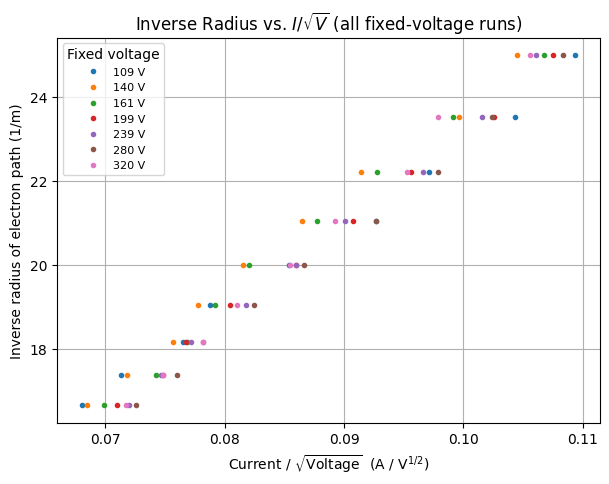

In [9]:
plt.figure(figsize=(7, 5))
for voltage, currents in zip(volts, curr):
    scaled_current = np.asarray(currents) / np.sqrt(voltage)
    plt.plot(scaled_current, inv_radius1, marker='.', ls='', label=f'{voltage} V')

plt.grid(True)
plt.title(r'Inverse Radius vs. $I/\sqrt{V}$ (all fixed-voltage runs)')
plt.xlabel(r'Current / $\sqrt{\mathrm{Voltage}}$  (A / V$^{1/2}$)')
plt.ylabel('Inverse radius of electron path (1/m)')
plt.legend(title='Fixed voltage', fontsize=8)
plt.show()
